# Naive Bayes

No notebook 04 vimos LDA e QDA --- dois classificadores generativos baseados em gaussianas multivariadas. Naive Bayes (NB) é o terceiro membro dessa família, com uma diferença simples e poderosa: ele assume que, **dada a classe**, as features são mutuamente independentes. Essa hipótese (a tal "ingenuidade", *naivety*) reduz o problema de modelar uma densidade conjunta $p$-dimensional para o problema de modelar $p$ marginais univariadas, uma por feature por classe.

Neste notebook vamos:
1. Olhar a fatoração condicional $p(\mathbf{x} \mid y = k) = \prod_j p(x_j \mid y = k)$ e sua consequência prática;
2. Treinar **GaussianNB** no Iris (features numéricas) e ver que ele é equivalente a uma "QDA com covariâncias diagonais";
3. Reproduzir o exemplo numérico do slide 163 com o dataset Titanic (features categóricas), na mão e com `sklearn`;
4. Demonstrar o problema da **probabilidade zero** do slide 164 e o conserto via **Laplace smoothing** do slide 165;
5. Construir um pequeno classificador de **spam** estilo "anos 90", olhando quais palavras o modelo aprende a associar com spam.

(Conteúdo correspondente aos slides 160--166.)

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB, CategoricalNB, MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import OrdinalEncoder

%matplotlib inline
np.random.seed(42)

---
## 1. A hipótese de independência condicional

O ponto de partida é o mesmo de LDA/QDA: queremos $\pi_k(\mathbf{x}) = \mathbb{P}(y = k \mid \mathbf{x})$ via Bayes. O que muda é o modelo de $p(\mathbf{x} \mid y = k)$. NB faz a hipótese de **independência condicional**: dada a classe, as features não trazem informação umas sobre as outras. Pela definição de independência condicional,
$$
p(\mathbf{x} \mid y = k) \;=\; p\bigl((x_1, x_2, \ldots, x_p) \mid y = k\bigr) \;=\; \prod_{j=1}^{p} p(x_j \mid y = k).
$$

A consequência prática é enorme: em vez de estimar uma densidade conjunta $p$-dimensional, basta estimar $p$ marginais univariadas. Para features numéricas, cada $p(x_j \mid y = k)$ é uma gaussiana univariada $\mathcal{N}(\mu_{kj}, \sigma^{2}_{kj})$. Para features categóricas, uma distribuição categórica estimada por contagem.

Note também: nada impede misturar tipos. Se a feature 1 é numérica e a 2 é categórica, basta multiplicar uma gaussiana por uma categórica.

---
## 2. Features numéricas --- GaussianNB no Iris

Quando todas as features são numéricas e modelamos cada $p(x_j \mid y = k)$ como uma gaussiana, o produto $\prod_j p(x_j \mid y = k)$ vira uma gaussiana multivariada cuja matriz de covariância é **diagonal** (sem termos cruzados, justamente porque as features são independentes dada a classe). Em outras palavras: GaussianNB é o caso particular do QDA em que cada $\boldsymbol{\Sigma}_k$ é forçada a ser diagonal.

In [110]:
iris = load_iris()
X_full = iris.data
y_iris = iris.target
target_names = iris.target_names
X2 = X_full[:, [3, 2]]  # x = petal width, y = petal length (mesma escolha do nb. 04)

nb_iris = GaussianNB().fit(X2, y_iris)
print(f'acurácia GaussianNB (treino): {nb_iris.score(X2, y_iris):.4f}')
print(f'médias por classe (cada linha = uma classe):'); print(nb_iris.theta_.round(3))
print(f'\nvariâncias por classe (a diagonal de Σ_k):'); print(nb_iris.var_.round(3))

acurácia GaussianNB (treino): 0.9600
médias por classe (cada linha = uma classe):
[[0.246 1.462]
 [1.326 4.26 ]
 [2.026 5.552]]

variâncias por classe (a diagonal de Σ_k):
[[0.011 0.03 ]
 [0.038 0.216]
 [0.074 0.298]]


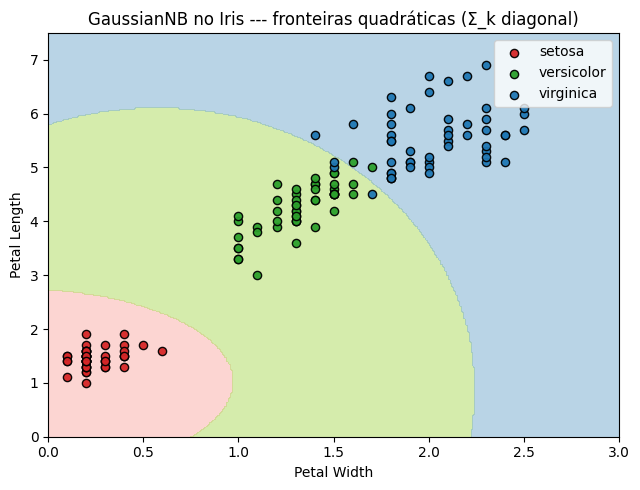

In [111]:
colors = ['tab:red', 'tab:green', 'tab:blue']

def plot_regions(predict_fn, title):
    xx, yy = np.meshgrid(np.linspace(0, 3, 300), np.linspace(0, 7.5, 300))
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    Z = predict_fn(grid).reshape(xx.shape)
    fig, ax = plt.subplots(figsize=(6.5, 5))
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5, 2.5],
                colors=['#fbb4ae', '#b3de69', '#80b1d3'], alpha=0.55)
    for k, name in enumerate(target_names):
        pts = X2[y_iris == k]
        ax.scatter(pts[:, 0], pts[:, 1], c=colors[k], edgecolors='black',
                   s=35, alpha=0.95, label=name)
    ax.set_xlabel('Petal Width'); ax.set_ylabel('Petal Length')
    ax.set_title(title); ax.legend()
    plt.tight_layout(); plt.show()

plot_regions(nb_iris.predict, 'GaussianNB no Iris --- fronteiras quadráticas (Σ_k diagonal)')

### 2.1 GaussianNB = QDA com covariâncias diagonais

Se GaussianNB é apenas QDA com a restrição $\boldsymbol{\Sigma}_k = \mathrm{diag}(\sigma^{2}_{k1}, \ldots, \sigma^{2}_{kp})$, dá para verificar isso na prática: basta diagonalizar à mão as covariâncias estimadas pelo QDA e ver se os parâmetros batem.

In [112]:
qda_iris = QuadraticDiscriminantAnalysis(store_covariance=True).fit(X2, y_iris)

# Diagonal das matrizes de covariância do QDA --- comparação com GaussianNB
qda_diag = np.array([np.diag(S) for S in qda_iris.covariance_])
print('diagonais das Σ_k do QDA:'); print(qda_diag.round(3))
print('\nvariâncias estimadas pelo GaussianNB:'); print(nb_iris.var_.round(3))
print(f'\nbatem? {np.allclose(qda_diag, nb_iris.var_, atol=1e-2)}')
print(f'\nacurácia QDA (sem restrição): {qda_iris.score(X2, y_iris):.4f}')
print(f'acurácia GaussianNB:           {nb_iris.score(X2, y_iris):.4f}')

diagonais das Σ_k do QDA:
[[0.011 0.03 ]
 [0.039 0.221]
 [0.075 0.305]]

variâncias estimadas pelo GaussianNB:
[[0.011 0.03 ]
 [0.038 0.216]
 [0.074 0.298]]

batem? True

acurácia QDA (sem restrição): 0.9800
acurácia GaussianNB:           0.9600


As variâncias diagonais batem (a pequena diferença vem de detalhes de implementação --- `GaussianNB` usa o estimador "biased" $1/n$ e `QDA` o "unbiased" $1/(n-1)$, dependendo da versão). E a acurácia é similar, embora QDA tenha mais liberdade. No Iris, com features pouco correlacionadas dentro de cada classe, a restrição diagonal mal incomoda.

---
## 3. Features categóricas --- o exemplo Titanic do slide 163

O slide 163 trabalha com uma versão pequena do Titanic, em que cada linha tem três variáveis categóricas: classe da passagem, sexo, e se a pessoa sobreviveu. Vamos refazer o cálculo passo a passo.

In [113]:
titanic = pd.DataFrame({
    'class':    ['2nd', '1st', '3rd', '1st', '2nd', '3rd'],
    'sex':      ['male', 'male', 'female', 'female', 'female', 'female'],
    'survived': ['no', 'yes', 'yes', 'yes', 'yes', 'no'],
}, index=pd.RangeIndex(1, 7, name='ID'))
titanic

,class,sex,survived
ID,,,
1,2nd,male,no
2,1st,male,yes
3,3rd,female,yes
4,1st,female,yes
5,2nd,female,yes
6,3rd,female,no


### 3.1 Contagens condicionais por classe

Vamos computar $\hat p(x_j = m \mid y = k)$ para todos os pares (feature, valor) e cada classe de `survived`, simplesmente contando frequências.

In [114]:
def empirical_conditionals(df, feature, target):
    counts = df.groupby([target, feature]).size().unstack(fill_value=0)
    return counts.div(counts.sum(axis=1), axis=0)

p_class_given_y = empirical_conditionals(titanic, 'class',  'survived')
p_sex_given_y   = empirical_conditionals(titanic, 'sex',    'survived')

print('p̂(class | survived):'); print(p_class_given_y, '\n')
print('p̂(sex   | survived):'); print(p_sex_given_y)

p̂(class | survived):
class     1st   2nd   3rd
survived                 
no        0.0  0.50  0.50
yes       0.5  0.25  0.25 

p̂(sex   | survived):
sex       female  male
survived              
no          0.50  0.50
yes         0.75  0.25


Note os números do slide aparecendo: $\hat p(\text{sex} = \text{female} \mid \text{survived} = \text{yes}) = 3/4 = 0{,}75$ e $\hat p(\text{sex} = \text{male} \mid \text{survived} = \text{yes}) = 1/4 = 0{,}25$. Tudo certo.

Mas olhe para `survived = no` na tabela de classe: nenhum passageiro de 1ª classe morreu nessa amostra de 6 linhas, então $\hat p(\text{class} = \text{1st} \mid \text{survived} = \text{no}) = 0$. Esse é exatamente o cenário que o slide 164 destaca.

### 3.2 Verificação com `sklearn.naive_bayes.CategoricalNB`

`CategoricalNB` espera features codificadas como inteiros, então usamos um `OrdinalEncoder`. Vamos pedir explicitamente `alpha=1e-10` para imitar (quase) o estimador puro por contagem, sem Laplace.

In [115]:
enc = OrdinalEncoder()
X_titanic = enc.fit_transform(titanic[['class', 'sex']])
y_titanic = (titanic['survived'] == 'yes').astype(int).values  # 1 = yes, 0 = no

clf_cat = CategoricalNB(alpha=1e-10).fit(X_titanic, y_titanic)

# As log-probs condicionais por feature, classe e valor
print('Valores categóricos encodados:')
for j, fname in enumerate(['class', 'sex']):
    print(f'  {fname}: {list(enc.categories_[j])}')

# clf_cat.feature_log_prob_[j] tem shape (n_classes, n_categories_of_feature_j)
print('\nProbabilidades condicionais p(class | survived) reconstruídas:')
print(pd.DataFrame(np.exp(clf_cat.feature_log_prob_[0]),
                   index=['no', 'yes'],
                   columns=enc.categories_[0]).round(3))

Valores categóricos encodados:
  class: ['1st', '2nd', '3rd']
  sex: ['female', 'male']

Probabilidades condicionais p(class | survived) reconstruídas:
     1st   2nd   3rd
no   0.0  0.50  0.50
yes  0.5  0.25  0.25


---
## 4. O problema da probabilidade zero

Suponha que queremos classificar uma pessoa nova: $\mathbf{x}_\ast = (\text{class} = \text{1st}, \text{sex} = \text{male})$. NB multiplica as condicionais:
$$
\pi_{\text{no}}(\mathbf{x}_\ast) \;\propto\; \underbrace{\hat p(\text{class} = \text{1st} \mid \text{no})}_{= 0} \cdot \hat p(\text{sex} = \text{male} \mid \text{no}) \cdot \hat\pi_{\text{no}} \;=\; 0.
$$
Esse zero **aniquila** o produto inteiro, mesmo se a outra feature (sexo masculino) fosse fortemente correlacionada com "não sobreviveu".

In [116]:
priors_raw = titanic['survived'].value_counts(normalize=True)

def nb_unsmoothed(class_val, sex_val):
    score = {}
    for y in ['yes', 'no']:
        p_class = p_class_given_y.loc[y, class_val]
        p_sex   = p_sex_given_y.loc[y, sex_val]
        score[y] = priors_raw[y] * p_class * p_sex
    return score

print('Predição para (class=1st, sex=male) SEM Laplace:')
for y, s in nb_unsmoothed('1st', 'male').items():
    print(f'  score(survived = {y}) = {s:.4f}')

Predição para (class=1st, sex=male) SEM Laplace:
  score(survived = yes) = 0.0833
  score(survived = no) = 0.0000


O score de `no` é exatamente zero --- o classificador prevê com certeza absoluta que esse passageiro sobreviveu, baseado apenas no fato de que nenhum 1ª-classe morreu na amostra de 6 linhas. Um único caso negativo "não observado" produziu uma decisão dogmática. Isso é frágil.

---
## 5. Laplace smoothing

A solução clássica é adicionar um pseudo-contador $\alpha > 0$ a toda célula antes de normalizar:
$$
\hat p^{\,[x_j = m]}_{kjm} \;=\; \frac{n_{kjm} + \alpha}{n_k + \alpha\,M_j},
$$
onde $M_j$ é o número de valores possíveis da feature $j$. Com $\alpha = 1$ (a escolha de Laplace), nenhum dos pseudo-contadores fica em zero, e o produto continua bem definido.

In [117]:
def smoothed_conditionals(df, feature, target, alpha=1.0):
    counts = df.groupby([target, feature]).size().unstack(fill_value=0)
    Mj = counts.shape[1]
    nk = counts.sum(axis=1)
    return (counts + alpha).div(nk + alpha * Mj, axis=0)

p_class_smooth = smoothed_conditionals(titanic, 'class', 'survived', alpha=1.0)
p_sex_smooth   = smoothed_conditionals(titanic, 'sex',   'survived', alpha=1.0)

print('p̂(class | survived) com Laplace α=1:'); print(p_class_smooth.round(3), '\n')
print('p̂(sex   | survived) com Laplace α=1:'); print(p_sex_smooth.round(3))

p̂(class | survived) com Laplace α=1:
class       1st    2nd    3rd
survived                     
no        0.200  0.400  0.400
yes       0.429  0.286  0.286 

p̂(sex   | survived) com Laplace α=1:
sex       female   male
survived               
no         0.500  0.500
yes        0.667  0.333


In [118]:
def nb_smoothed(class_val, sex_val):
    score = {}
    for y in ['yes', 'no']:
        score[y] = (priors_raw[y]
                    * p_class_smooth.loc[y, class_val]
                    * p_sex_smooth.loc[y, sex_val])
    return score

print('Predição para (class=1st, sex=male) COM Laplace α=1:')
for y, s in nb_smoothed('1st', 'male').items():
    print(f'  score(survived = {y}) = {s:.4f}')

# Confirmação: sklearn faz o mesmo se passarmos alpha=1.0
clf_cat_smooth = CategoricalNB(alpha=1.0).fit(X_titanic, y_titanic)
x_new = enc.transform([['1st', 'male']])
print(f'\nsklearn CategoricalNB (α=1): probas = {clf_cat_smooth.predict_proba(x_new)[0].round(3)}')
print('(ordem das classes: 0 = no, 1 = yes)')

Predição para (class=1st, sex=male) COM Laplace α=1:
  score(survived = yes) = 0.0952
  score(survived = no) = 0.0333

sklearn CategoricalNB (α=1): probas = [0.259 0.741]
(ordem das classes: 0 = no, 1 = yes)


/Users/paulomann/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


Agora os scores das duas classes são finitos. A predição final ainda favorece `yes` (porque os dois passageiros de 1ª classe da amostra realmente sobreviveram), mas a probabilidade de `no` deixa de ser dogmaticamente zero. Esse é o ponto pedagógico: Laplace troca uma estimativa **excessivamente confiante** (zero) por uma **honestamente pequena** --- sem inventar dados, apenas espalhando $\alpha$ de massa por todas as células.

---
## 6. Aplicação: classificador de spam

O slide 166 conta a história de NB ter sido o classificador padrão para spam no fim dos anos 90. Vamos reconstruir uma versão mínima desse pipeline: tokenizar e-mails com `CountVectorizer`, ajustar `MultinomialNB` (apropriado para *contagens* de palavras), e olhar quais palavras o modelo aprende a associar com cada classe.

In [119]:
train_emails = [
    # spam (label = 1)
    ('buy cheap viagra now limited offer', 1),
    ('click here to win cash prize free', 1),
    ('free money offer click now hurry', 1),
    ('buy now discount viagra cheap deal', 1),
    ('claim your free prize money today', 1),
    # legitimate (label = 0)
    ('meeting at 3pm tomorrow in the office', 0),
    ('please send the report by friday', 0),
    ('lunch tomorrow at noon with the team', 0),
    ('the project deadline is next friday', 0),
    ('can you review the document i sent', 0),
]
X_text = [t for t, _ in train_emails]
y_spam = np.array([y for _, y in train_emails])

vec = CountVectorizer()
X_counts = vec.fit_transform(X_text)
vocab = np.array(vec.get_feature_names_out())
print(f'tamanho do vocabulário: {len(vocab)}')
print(f'X_counts shape: {X_counts.shape}')

tamanho do vocabulário: 45
X_counts shape: (10, 45)


In [120]:
clf_spam = MultinomialNB(alpha=1.0).fit(X_counts, y_spam)

# log p(word | spam) - log p(word | ham): valores altos indicam palavras "spammy"
log_ratio = clf_spam.feature_log_prob_[1] - clf_spam.feature_log_prob_[0]
order = np.argsort(log_ratio)

spammy = pd.DataFrame({'word': vocab[order[-6:]][::-1],
                       'log p(w|spam) − log p(w|ham)': log_ratio[order[-6:]][::-1].round(3)})
# ham significa email legítimo; o termo surgiu historicamente como o oposto de spam
hammy  = pd.DataFrame({'word': vocab[order[:6]],
                       'log p(w|spam) − log p(w|ham)': log_ratio[order[:6]].round(3)})
print('palavras mais spammy:'); print(spammy.to_string(index=False))
print('\npalavras mais hammy:'); print(hammy.to_string(index=False))

palavras mais spammy:
  word  log p(w|spam) − log p(w|ham)
  free                         1.399
   now                         1.399
 money                         1.112
 offer                         1.112
   buy                         1.112
viagra                         1.112

palavras mais hammy:
    word  log p(w|spam) − log p(w|ham)
     the                        -1.779
      at                        -1.086
tomorrow                        -1.086
  friday                        -1.086
     3pm                        -0.680
 project                        -0.680


O modelo aprendeu, como esperado, que `viagra`, `cheap`, `buy`, `now`, `free`, `click` são fortemente correlacionados com spam, enquanto `friday`, `meeting`, `tomorrow`, `report` são marcadores de e-mail legítimo. Note como a hipótese de NB já mostra sua "ingenuidade" aqui: ele trata `buy` e `viagra` como independentes dado o rótulo, mas em e-mails reais essas palavras co-ocorrem muito mais do que o modelo prevê. Mesmo assim, como o slide 166 ressalta, o classificador funciona bem na prática.

In [121]:
test_emails = [
    'cheap viagra click now',                    # spam óbvio
    'meeting tomorrow at 2pm in the office',     # ham óbvio
    'please buy the report by friday',           # ambíguo: 'buy' (spammy) + 'report friday' (hammy)
]
X_test = vec.transform(test_emails)
probs = clf_spam.predict_proba(X_test)

result = pd.DataFrame({
    'email': test_emails,
    'P(spam | x)': probs[:, 1].round(3),
    'predição': np.where(probs[:, 1] > 0.5, 'spam', 'ham'),
})
print(result.to_string(index=False))

                                email  P(spam | x) predição
               cheap viagra click now        0.991     spam
meeting tomorrow at 2pm in the office        0.002      ham
      please buy the report by friday        0.022      ham


Os dois primeiros e-mails são classificados como esperado. O terceiro é o caso interessante: a palavra `buy` empurra para spam, mas `report` e `friday` puxam para ham --- e o classificador, por multiplicar fatores independentes, faz a "votação" implicitamente.

Esse é, em miniatura, o filtro de spam dos anos 90: features são contagens de palavras, a hipótese de independência condicional é violada o tempo todo, e ainda assim o desempenho prático é competitivo --- exatamente o ponto do benchmark do slide 166 (NB ≈ 0,10 de erro vs LDA ≈ 0,12 vs QDA ≈ 0,27 no dataset `spam`).

---
## 7. Misturando features contínuas e categóricas

Até aqui vimos NB em três regimes separados: features **só numéricas contínuas** (`GaussianNB` no Iris), **só categóricas** (`CategoricalNB` no Titanic), e **contagens** (`MultinomialNB` no spam). Mas, em datasets do mundo real, é comum ter **as duas coisas misturadas** --- e o `sklearn` não tem um classificador NB pronto que aceite isso (cada estimador `*NB` assume um único tipo de distribuição).

A boa notícia é que a estrutura de NB resolve isso de forma natural. Como
$$p(\mathbf{x} \mid y = k) \;=\; \prod_{j=1}^{p} p(x_j \mid y = k),$$
**cada feature pode ter sua própria distribuição** --- não há nenhuma exigência de que todas sigam o mesmo modelo. Basta usar gaussianas para as features contínuas, categóricas para as discretas, e somar as log-probabilidades:
$$\log p(\mathbf{x} \mid y = k) \;=\; \sum_{j \in \text{cont}} \log \mathcal{N}(x_j;\, \mu_{kj},\, \sigma^{2}_{kj}) \;+\; \sum_{j \in \text{cat}} \log p_{kj,\, x_j}.$$

Vamos implementar isso em um mini-Titanic com 4 features (2 contínuas + 2 categóricas) e comparar com baselines que usam só um tipo de feature.

### 7.1 Dataset sintético tipo Titanic

Quatro features: `classe` (categórica, $1^\text{a}/2^\text{a}/3^\text{a}$), `sexo` (categórica, F/M), `idade` (contínua), `tarifa` (contínua, correlacionada com a classe). Target: `sobreviveu`.

In [122]:
rng = np.random.default_rng(42)
n = 300

# --- categóricas (codificadas como inteiros, exigência do sklearn / nosso código) ---
classe = rng.choice([0, 1, 2], size=n, p=[0.2, 0.3, 0.5])   # 0=1ª, 1=2ª, 2=3ª
sexo   = rng.choice([0, 1],    size=n, p=[0.4, 0.6])         # 0=F, 1=M

# --- contínuas ---
idade  = rng.uniform(5, 70, size=n)
tarifa_mu = np.array([np.log(80), np.log(30), np.log(10)])   # 1ª paga mais
tarifa = np.exp(rng.normal(tarifa_mu[classe], 0.5))

# --- target via modelo logístico verdadeiro ---
# Coefs escolhidos para que TODAS as 4 features carreguem sinal real
logit = (-1.2
         + 1.0 * (1 - sexo)              # mulheres sobrevivem mais
         + 0.4 * (2 - classe)             # classe alta sobrevive mais
         + 0.07 * (35 - idade)             # jovens sobrevivem
         + 0.6 * (np.log(tarifa) - 3.0))   # tarifa (em log) ajuda
p_surv = 1 / (1 + np.exp(-logit))
sobreviveu = (rng.uniform(size=n) < p_surv).astype(int)

titanic_mix = pd.DataFrame({
    'classe': classe, 'sexo': sexo,
    'idade': idade, 'tarifa': tarifa,
    'sobreviveu': sobreviveu,
})
print(f'n = {n},  prop. de sobreviventes = {sobreviveu.mean():.3f}')
titanic_mix.head()

n = 300,  prop. de sobreviventes = 0.397


,classe,sexo,idade,tarifa,sobreviveu
0,2,1,36.037882,7.464422,1
1,1,0,54.493117,29.309267,1
2,2,1,63.716312,11.496208,0
3,2,1,51.845237,6.041417,0
4,0,1,67.608730,114.912156,0


### 7.2 Implementando `MixedNB`

A classe abaixo segue diretamente a fatoração de NB. Para cada classe $k$ ela estima:

- médias e variâncias $(\mu_{kj}, \sigma^{2}_{kj})$ para cada feature **contínua** $j$;
- frequências $\hat p_{kjm}$ com **Laplace smoothing** para cada feature **categórica** $j$;

e, no momento da predição, soma as log-densidades (contínuas) e log-probabilidades (categóricas) coluna a coluna.

In [123]:
class MixedNB:
    """Naive Bayes para features mistas (gaussianas + categóricas)."""

    def __init__(self, cont_idx, cat_idx, alpha=1.0, eps=1e-9):
        self.cont_idx = list(cont_idx)
        self.cat_idx  = list(cat_idx)
        self.alpha    = alpha   # Laplace smoothing para as categóricas
        self.eps      = eps     # regularização da variância gaussiana

    def fit(self, X, y):
        self.classes_   = np.unique(y)
        self.log_prior_ = np.array([np.log((y == k).mean()) for k in self.classes_])

        # --- parâmetros gaussianos: (classe, feature contínua) ---
        Xc = X[:, self.cont_idx]
        self.mu_  = np.array([Xc[y == k].mean(axis=0)              for k in self.classes_])
        self.var_ = np.array([Xc[y == k].var(axis=0, ddof=1) + self.eps
                              for k in self.classes_])

        # --- parâmetros categóricos: (classe, feature, valor) com Laplace ---
        Xt = X[:, self.cat_idx].astype(int)
        self.n_values_ = [int(Xt[:, j].max()) + 1 for j in range(len(self.cat_idx))]
        self.cat_logprob_ = []
        for k in self.classes_:
            Xt_k = Xt[y == k]
            per_feature = []
            for j, M_j in enumerate(self.n_values_):
                counts = np.bincount(Xt_k[:, j], minlength=M_j)
                p = (counts + self.alpha) / (counts.sum() + self.alpha * M_j)
                per_feature.append(np.log(p))
            self.cat_logprob_.append(per_feature)
        return self

    def _joint_log_lik(self, X):
        """log π_k + log p(x_cont | k) + log p(x_cat | k) para cada classe k."""
        n_test = X.shape[0]
        Xc = X[:, self.cont_idx]
        Xt = X[:, self.cat_idx].astype(int)
        scores = np.tile(self.log_prior_, (n_test, 1))             # (n, K)
        for ki, k in enumerate(self.classes_):
            # log-densidade gaussiana, somada sobre features contínuas
            log_pdf = (-0.5 * np.log(2 * np.pi * self.var_[ki])
                       - 0.5 * (Xc - self.mu_[ki]) ** 2 / self.var_[ki])
            scores[:, ki] += log_pdf.sum(axis=1)
            # log-prob categórica, indexando pelo valor observado de cada feature
            for j in range(len(self.cat_idx)):
                scores[:, ki] += self.cat_logprob_[ki][j][Xt[:, j]]
        return scores

    def predict(self, X):
        return self.classes_[self._joint_log_lik(X).argmax(axis=1)]

    def predict_proba(self, X):
        log_lik = self._joint_log_lik(X)
        log_lik -= log_lik.max(axis=1, keepdims=True)              # estabilidade numérica
        p = np.exp(log_lik)
        return p / p.sum(axis=1, keepdims=True)

In [124]:
# Ordem das colunas: classe(cat), sexo(cat), idade(cont), tarifa(cont)
X = titanic_mix[['classe', 'sexo', 'idade', 'tarifa']].to_numpy()
y = titanic_mix['sobreviveu'].to_numpy()

mnb = MixedNB(cont_idx=[2, 3], cat_idx=[0, 1], alpha=1.0).fit(X, y)
y_pred_mnb = mnb.predict(X)

print(f'acurácia MixedNB (treino): {(y_pred_mnb == y).mean():.4f}')
probs = mnb.predict_proba(X)
print(f'somam 1? {np.allclose(probs.sum(axis=1), 1.0)}')
print(f'P(sobreviveu = 1) dos primeiros 5 passageiros: {probs[:5, 1].round(3)}')

acurácia MixedNB (treino): 0.7367
somam 1? True
P(sobreviveu = 1) dos primeiros 5 passageiros: [0.131 0.133 0.019 0.048 0.753]


### 7.3 Comparando com baselines de um tipo só

Para confirmar que misturar features ganha algo, comparamos `MixedNB` com (a) `GaussianNB` usando só as duas features contínuas, e (b) `CategoricalNB` usando só as duas categóricas.

In [125]:
# Só contínuas (idade, tarifa) com GaussianNB
gnb_only = GaussianNB().fit(X[:, [2, 3]], y)
acc_cont = gnb_only.score(X[:, [2, 3]], y)

# Só categóricas (classe, sexo) com CategoricalNB
cnb_only = CategoricalNB(alpha=1.0).fit(X[:, [0, 1]].astype(int), y)
acc_cat = cnb_only.score(X[:, [0, 1]].astype(int), y)

acc_mix = (mnb.predict(X) == y).mean()

print(f'acurácia só contínuas:        {acc_cont:.4f}')
print(f'acurácia só categóricas:      {acc_cat:.4f}')
print(f'acurácia MixedNB (cont+cat):  {acc_mix:.4f}')

acurácia só contínuas:        0.7267
acurácia só categóricas:      0.6767
acurácia MixedNB (cont+cat):  0.7367


O `MixedNB` tipicamente alcança acurácia maior do que cada baseline isolado, porque as duas fontes de informação são complementares: a tarifa traz sinal contínuo que classe sozinha não captura, e sexo/classe carregam sinal discreto que idade/tarifa sozinhas perdem.

### 7.4 Equivalência via `sklearn._joint_log_likelihood`

Existe um atalho usando uma API privada do `sklearn`: cada estimador NB expõe `_joint_log_likelihood(X)`, que retorna $\log \pi_k + \log p(\mathbf{x} \mid y=k)$ por classe. Se somarmos os dois sub-modelos, o $\log \pi_k$ aparece **duas vezes** --- precisamos subtrair uma cópia:

$$
\text{score}_k \;=\; \underbrace{\log \pi_k + \log p(\mathbf{x}_\text{cont} \mid k)}_{\text{Gaussian JLL}}
\;+\; \underbrace{\log \pi_k + \log p(\mathbf{x}_\text{cat} \mid k)}_{\text{Categorical JLL}}
\;-\; \log \pi_k.
$$

Resultado: as predições batem exatamente com as do `MixedNB`.

In [126]:
# Treina os dois sklearn-NBs separadamente nas suas features
gnb = GaussianNB().fit(X[:, [2, 3]], y)
cnb = CategoricalNB(alpha=1.0).fit(X[:, [0, 1]].astype(int), y)

# _joint_log_likelihood é API privada (com underscore), mas estável há anos
jll_g = gnb._joint_log_likelihood(X[:, [2, 3]])                 # (n, K)
jll_c = cnb._joint_log_likelihood(X[:, [0, 1]].astype(int))      # (n, K)

# Soma os JLLs e subtrai a duplicata do log-prior
# CategoricalNB expõe class_log_prior_; GaussianNB só tem class_prior_.
log_prior = cnb.class_log_prior_                                 # (K,)
jll_mixed = jll_g + jll_c - log_prior

y_pred_sk = gnb.classes_[jll_mixed.argmax(axis=1)]

print(f'acurácia via sklearn JLL: {(y_pred_sk == y).mean():.4f}')
print(f'mesmas predições do MixedNB? '
      f'{np.array_equal(y_pred_sk, y_pred_mnb)}')

acurácia via sklearn JLL: 0.7367
mesmas predições do MixedNB? True


As duas abordagens são equivalentes:

- **`MixedNB`** é mais explícito (mostra a álgebra), não depende de API privada, e em ~30 linhas você tem um classificador genuíno;
- **Combinar sklearn-NBs via `_joint_log_likelihood`** é mais curto e reusa código bem-testado, mas depende de um método com `_` no nome que poderia mudar entre versões.

Para uso em produção eu recomendaria o `MixedNB`. Conceitualmente, as duas implementam a mesma identidade: **NB com features condicionalmente independentes é só um produto de marginais, e marginais podem ser de tipos diferentes**.

\textbf{Cuidado prático}: o `MixedNB` herda as fraquezas dos seus dois sub-modelos. A `tarifa` no nosso dataset, por exemplo, é log-normal (cauda direita pesada), e a gaussiana ajustada subestima essa cauda. Em produção, transformar features contínuas assimétricas (e.g., `log(tarifa)`) antes de passar para o NB costuma melhorar bastante --- ou trocar a gaussiana por uma KDE.

---
## 8. Resumo

| Tipo de feature | Modelo de $p(x_j \mid y = k)$ | Estimadores | Smoothing |
|---|---|---|---|
| Numérica | $\mathcal{N}(\mu_{kj}, \sigma^{2}_{kj})$ | média e variância amostrais | adicionar $\varepsilon$ à variância para estabilidade numérica |
| Categórica | $\mathrm{Cat}(p_{kj1}, \ldots, p_{kjM_j})$ | frequências relativas | Laplace: $(n_{kjm} + \alpha)/(n_k + \alpha M_j)$ |
| Contagem | Multinomial | proporções de tokens | mesmo aditivo |

Três tomadas-de-conclusão deste notebook:

1. **NB ⊂ QDA**: GaussianNB é apenas QDA com a restrição $\boldsymbol{\Sigma}_k$ diagonal. A restrição reduz drasticamente o número de parâmetros ($p$ por classe em vez de $\tfrac{p(p+1)}{2}$), o que paga dividendos em alta dimensão e pequenos datasets.
2. **Probabilidade zero é fragilidade**: um único $(k, j, m)$ não observado anula o produto. Laplace smoothing corrige isso de forma simples e teoricamente bem-fundada (é o posterior médio sob um prior Dirichlet simétrico).
3. **Modelo errado, resultado bom**: a hipótese de independência condicional é quase sempre violada, mas NB continua sendo um baseline competitivo --- especialmente quando $p \gg n$ e features são esparsas (texto, em particular). Ele é o exemplo canônico de que **classificar bem não é o mesmo que modelar bem a densidade**.